In [43]:
%load_ext autoreload
%autoreload 2

import glob
import sys, os

import pandas as pd
import matplotlib.pyplot as plt
import shap
import seaborn as sns
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# CONFIG

In [ ]:
BASE_DIR              = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()

PATH_EXTRA_DATA       = os.path.join(BASE_DIR, "../data/extra/")
PATH_TRAFFIC          = os.path.join(BASE_DIR, "../data/traffic/")
FILEPATH_RICH         = os.path.join(BASE_DIR, "../data/richtingen.csv")
FILEPATH_SITE         = os.path.join(BASE_DIR, "../data/sites.csv")

FILEPATH_INFRA        = PATH_EXTRA_DATA + "sites_enriched_clean_new.csv"

FILEPATH_POP_TIF      = PATH_EXTRA_DATA + "bel_pop_2025_CN_100m_R2025A_v1.tif"
FILEPATH_WEATHER      = PATH_EXTRA_DATA + "site_id_weather_output.csv"

TRAFFIC_COLS  = ['site_id', 'direction', 'type', 'from', 'to', 'count']
RICH_COLS     = ['site_id', 'direction', 'name']
SITE_COLS     = ['site_id', 'site_nr', 'longtitude', 'latitude', 'name', 'domain', 'road_nbr','district_nbr', 'municipality', 'interval', 'date_installed']

In [13]:
sys.path.insert(-1, BASE_DIR)
import mda_lib

# EDA

## 1. Richtingen Data

In [ ]:
df_rich = pd.read_csv(FILEPATH_RICH, header=None, names=RICH_COLS)
print(df_rich.shape)
display(df_rich.describe())
display(df_rich.info())
df_rich.head()

(305, 3)


,site_id
count,305.000000
mean,75.406557
std,43.980168
min,1.000000
25%,37.000000
50%,75.000000
75%,113.000000
max,152.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   site_id    305 non-null    int64 
 1   direction  305 non-null    object
 2   name       305 non-null    object
dtypes: int64(1), object(2)
memory usage: 7.3+ KB


None

,site_id,direction,name
0,1,IN,Machelen Cyclists rich. Brucargo
1,1,OUT,Machelen Cyclists richting Machelen
2,2,IN,Brasschaat 2 Fietsers rich Merksem
3,2,OUT,Brasschaat 2 Fietsers rich Brasschaat
4,3,IN,Brasschaat 1 Fietsers rich Merksem


In [ ]:
print('n_unique site_id:', df_rich['site_id'].nunique())
print(df_rich["site_id"].value_counts())

df_rich[~df_rich['direction'].isin(['IN','OUT'])]

n_unique site_id: 151
site_id
1      3
102    3
34     3
7      3
110    2
      ..
54     2
55     2
41     2
152    2
141    1
Name: count, Length: 151, dtype: int64


,site_id,direction,name,from,to
37,7,IN/OUT,Evergem_1 [Debug],Evergem_1,[Debug]
44,34,IN/OUT,Heers_1 [Debug],Heers_1,[Debug]
194,102,IN/OUT,Diest_2 [Bike],Diest_2,[Bike]
240,1,IN/OUT,Machelen [Debug],Machelen,[Debug]


- There are 4 site_id with direction "IN/ OUT", together with invalid "debug" status from to, indicating that these observations can be elimiated in next steps

## 2. Sites Data

In [ ]:
df_site = pd.read_csv(FILEPATH_SITE, header=None, names=SITE_COLS)
df_site["date_installed"] = pd.to_datetime(df_site["date_installed"])
df_site["start_year"] = df_site["date_installed"].dt.year
print(df_site.shape)
display(df_site.describe())
display(df_site.info())
df_site.head()

(151, 11)


,site_id,site_nr,longtitude,latitude,interval
count,151.000000,1.510000e+02,151.000000,151.000000,151.000000
mean,76.145695,2.655954e+08,4.364879,51.010527,14.801325
std,43.951245,7.575055e+07,0.810268,0.154309,4.578238
min,1.000000,1.000389e+08,2.742890,50.751280,0.000000
25%,38.500000,3.000235e+08,3.768264,50.886897,15.000000
50%,76.000000,3.000256e+08,4.471690,50.990394,15.000000
75%,113.500000,3.000273e+08,4.937732,51.134365,15.000000
max,152.000000,3.000621e+08,5.797260,51.357520,60.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   site_id         151 non-null    int64  
 1   site_nr         151 non-null    int64  
 2   longtitude      151 non-null    float64
 3   latitude        151 non-null    float64
 4   name            151 non-null    object 
 5   domain          151 non-null    object 
 6   road_nbr        148 non-null    object 
 7   district_nbr    148 non-null    object 
 8   municipality    150 non-null    object 
 9   interval        151 non-null    int64  
 10  date_installed  151 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 13.1+ KB


None

,site_id,site_nr,longtitude,latitude,name,domain,road_nbr,district_nbr,municipality,interval,date_installed
0,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22
1,2,100052862,4.471690,51.275120,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22
2,3,100052863,4.472220,51.275030,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22
3,4,100052864,5.190110,51.160230,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
4,5,100052865,5.190030,51.160180,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22


In [ ]:
# Number of sites by municipalities
df_site.groupby("municipality")["site_id"].nunique().sort_values(ascending=False).head(15).reset_index(name="number_of_sites")

,municipality,number_of_sites
0,Brugge,7
1,Leuven,6
2,Kortrijk,5
3,District Vilvoorde-gewestwegen,4
4,Westerlo,4
5,Nieuwpoort,4
6,Gent,4
7,Hasselt,3
8,District Leuven,3
9,Aalst,3


In [ ]:
# Number of sites over years
active_sites_by_year = []
for year in sorted(df_site["start_year"].dropna().unique()):
    active_sites = df_site.loc[df_site["start_year"] <= year, "site_id"].nunique()
    active_sites_by_year.append({"year": int(year),"active_unique_sites": active_sites})
print(f'First day of installment:  {df_site['date_installed'].min()}\nLatest day of installment: {df_site['date_installed'].max()}')
pd.DataFrame(active_sites_by_year)

First day of installment:  2019-08-22 00:00:00
Latest day of installment: 2025-10-31 00:00:00


,year,active_unique_sites
0,2019,24
1,2020,25
2,2021,27
3,2022,129
4,2023,142
5,2024,143
6,2025,151


- From 2022, number of sites increased significantly from 27 in 2021 to 129 in 2022. Then this figure increases gradually over year to 151 in 2026

## 3. Traffic Data

In [ ]:
traffic_columns=['site_id', 'direction', 'type', 'from', 'to', 'count']
traffic_files = sorted(glob.glob(os.path.join(PATH_TRAFFIC, "data-20*.csv")))
df_traffic = pd.concat([pd.read_csv(f, names=traffic_columns) for f in traffic_files], ignore_index=True)
df_traffic[df_traffic["type"] == "FIETSERS"]

print(df_traffic.shape)
display(df_traffic.info())
display(df_traffic.describe())
display(df_traffic.head())

(42771848, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42771848 entries, 0 to 42771847
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   site_id    int64  
 1   direction  object 
 2   type       object 
 3   from       object 
 4   to         object 
 5   count      float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.9+ GB


None

,site_id,count
count,4.277185e+07,4.169401e+07
mean,6.288308e+01,2.593296e+00
std,4.225063e+01,7.106095e+00
min,1.000000e+00,0.000000e+00
25%,2.300000e+01,0.000000e+00
50%,5.900000e+01,0.000000e+00
75%,9.900000e+01,2.000000e+00
max,1.520000e+02,5.402000e+03


,site_id,direction,type,from,to,count
0,1,IN,FIETSERS,2019-08-01 00:00:00.0,2019-08-01 00:15:00.0,0.0
1,1,IN,FIETSERS,2019-08-01 00:15:00.0,2019-08-01 00:30:00.0,0.0
2,1,IN,FIETSERS,2019-08-01 00:30:00.0,2019-08-01 00:45:00.0,0.0
3,1,IN,FIETSERS,2019-08-01 00:45:00.0,2019-08-01 01:00:00.0,0.0
4,1,IN,FIETSERS,2019-08-01 01:00:00.0,2019-08-01 01:15:00.0,1.0


In [ ]:
df_traffic["from"] = pd.to_datetime(df_traffic["from"], errors="coerce")
df_traffic["to"] = pd.to_datetime(df_traffic["to"], errors="coerce")
df_traffic["count"] = pd.to_numeric(df_traffic["count"], errors="coerce")
df_traffic["year"] = df_traffic["from"].dt.year
df_traffic["month"] = df_traffic["from"].dt.month
df_traffic["year_month"] = df_traffic["from"].dt.strftime("%Y-%m")
df_traffic["date"] = df_traffic["from"].dt.date
df_traffic["hour"] = df_traffic["from"].dt.hour
df_traffic["datehour"] = (pd.to_datetime(df_traffic["from"].dt.strftime("%Y-%m-%d")) + pd.to_timedelta(df_traffic["from"].dt.hour, unit="h"))

print('number of site:', df_traffic['site_id'].nunique())
print('min date traffic:', df_traffic['to'].min(), ' max date traffic:', df_traffic['to'].min())
df_traffic.head()

number of site: 150
min date traffic: 2019-08-01 00:15:00  max date traffic: 2019-08-01 00:15:00


,site_id,direction,type,from,to,count,year,month,year_month,date,hour,datehour
0,1,IN,FIETSERS,2019-08-01 00:00:00,2019-08-01 00:15:00,0.0,2019,8,2019-08,2019-08-01,0,2019-08-01 00:00:00
1,1,IN,FIETSERS,2019-08-01 00:15:00,2019-08-01 00:30:00,0.0,2019,8,2019-08,2019-08-01,0,2019-08-01 00:00:00
2,1,IN,FIETSERS,2019-08-01 00:30:00,2019-08-01 00:45:00,0.0,2019,8,2019-08,2019-08-01,0,2019-08-01 00:00:00
3,1,IN,FIETSERS,2019-08-01 00:45:00,2019-08-01 01:00:00,0.0,2019,8,2019-08,2019-08-01,0,2019-08-01 00:00:00
4,1,IN,FIETSERS,2019-08-01 01:00:00,2019-08-01 01:15:00,1.0,2019,8,2019-08,2019-08-01,1,2019-08-01 01:00:00


In [ ]:
df_traffic[df_traffic['date'] == datetime.date(2019, 8, 1)].query('site_id==1').query('hour==0').groupby('from').size()

from
2019-08-01 00:00:00    2
2019-08-01 00:15:00    2
2019-08-01 00:30:00    2
2019-08-01 00:45:00    2
dtype: int64

- There are total 150 sites from `2019-08-01 00:15:00` to `2019-08-01 00:15:00`
- Traffic of each site is recorded every 15 minutes for 2 directions including `IN` and `OUT`

#### Traffic by time

In [ ]:
df_traffic.head()

,site_id,direction,type,from,to,count,year,month,hour,date,year_month
0,1,IN,FIETSERS,2019-08-01 00:00:00,2019-08-01 00:15:00,0.0,2019,8,0,2019-08-01,2019-08
1,1,IN,FIETSERS,2019-08-01 00:15:00,2019-08-01 00:30:00,0.0,2019,8,0,2019-08-01,2019-08
2,1,IN,FIETSERS,2019-08-01 00:30:00,2019-08-01 00:45:00,0.0,2019,8,0,2019-08-01,2019-08
3,1,IN,FIETSERS,2019-08-01 00:45:00,2019-08-01 01:00:00,0.0,2019,8,0,2019-08-01,2019-08
4,1,IN,FIETSERS,2019-08-01 01:00:00,2019-08-01 01:15:00,1.0,2019,8,1,2019-08-01,2019-08


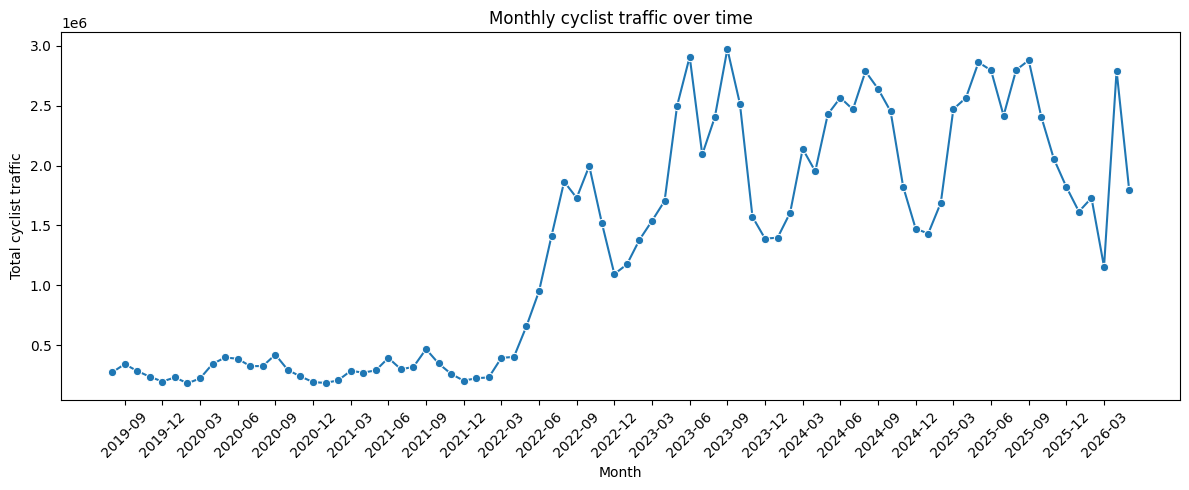

In [ ]:
monthly_traffic = (
    df_traffic.groupby(["year_month"], as_index=False)["count"]
    .sum()
    .rename(columns={"count": "total_cyclist_traffic"})
)
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_traffic, x="year_month", y="total_cyclist_traffic", marker="o")
plt.title("Monthly cyclist traffic over time")
plt.xlabel("Month")
plt.ylabel("Total cyclist traffic")

xticks = monthly_traffic["year_month"].tolist()
plt.xticks(ticks=range(1, len(xticks), 3), labels=[xticks[i] for i in range(1, len(xticks), 3)], rotation=45)
plt.tight_layout()
plt.savefig('monthly_traffic_by_year.png')
plt.show()

- We zoom into the period of 01-2025 to 03-2026 to see patterns of traffic by temporal aspects.
- In stead of looking into 15-minute interval, we track traffic by each hour for efficient computing

In [ ]:
df_traffic_hourly = (
    df_traffic.query('year_month>="2025-01"').query('year_month<="2026-03"')
    .groupby(["site_id", "year_month", "datehour"], as_index=False)["count"].sum()
    .merge(df_site[['site_id','municipality']], on="site_id", how="left")
    .rename(columns={'count':'traffic_total'}).reset_index(drop=True)
)
print(df_traffic_hourly['datehour'].min(), df_traffic_hourly['datehour'].max())
display(df_traffic_hourly.head())

2025-01-01 00:00:00 2026-03-14 03:00:00


,site_id,year_month,datehour,traffic_total,municipality
0,1,2025-01,2025-01-01 00:00:00,1.0,Machelen
1,1,2025-01,2025-01-01 01:00:00,2.0,Machelen
2,1,2025-01,2025-01-01 02:00:00,3.0,Machelen
3,1,2025-01,2025-01-01 03:00:00,2.0,Machelen
4,1,2025-01,2025-01-01 04:00:00,1.0,Machelen


In [ ]:
df_traffic_hourly['municipality'].nunique(),df_traffic_hourly['municipality'].unique()

(71,
 array(['Machelen', 'Brasschaat', 'Balen', 'Evergem', 'Heist-op-den-Berg',
        'Aalst', 'Kraainem', 'Gent', 'Genk', 'Oostende', 'Kortrijk',
        'Brugge', 'Bilzen', 'Tienen', 'Bree', 'Zaventem', 'Meise', 'Heers',
        'Tongeren', 'Herk-de-Stad', 'Lummen', 'Lanaken', 'Lommel', 'Peer',
        'Maasmechelen', 'Maaseik', 'Pelt', 'Vilvoorde', 'As', 'Torhout',
        'Meulebeke', 'Ardooie', 'Wervik', 'Nieuwpoort', 'Ieper', 'Leuven',
        'Kampenhout', 'Herent', 'Pepingen', 'Wemmel', 'Beersel', 'Izegem',
        'Asse', 'Aarschot', 'Westerlo', 'Brecht', 'Nijlen', 'Herentals',
        'Lier', 'Geel', 'Mechelen', 'Diest', 'Malle', 'Halle',
        'Sint-Pieters-Leeuw', 'Zemst', 'Deinze', 'Nazareth', 'Aalter',
        'Melle', 'Zele', 'Dendermonde', 'Beveren', 'Hamme', 'Lokeren',
        'Lille', 'Dessel', 'Hasselt', 'Houthalen-Helchteren',
        'District Vilvoorde-gewestwegen', 'District Leuven', nan],
       dtype=object))

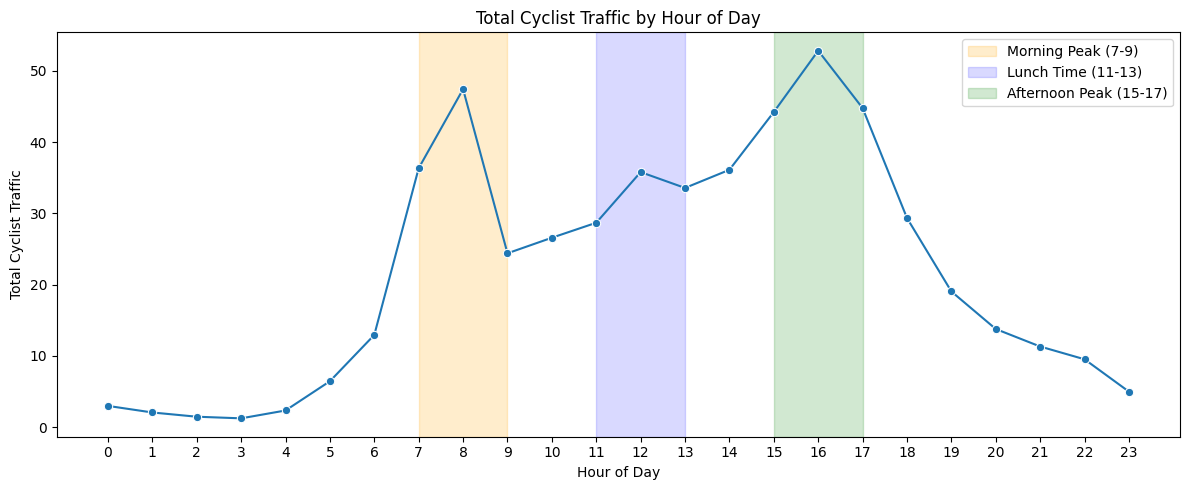

In [ ]:
# Plot total traffic by hour of the day from df_traffic_hourly as a line chart
# and highlight morning ([7,8,9]), lunch ([11,12,13]), and afternoon ([15,16,17]) periods.

# Ensure 'datehour' is datetime and extract hour
df_traffic_hourly['hour'] = pd.to_datetime(df_traffic_hourly['datehour']).dt.hour

# Aggregate total traffic per hour of day
traffic_by_hour = df_traffic_hourly.groupby('hour')['traffic_total'].mean().reset_index()

# Plot as line chart
plt.figure(figsize=(12, 5))
sns.lineplot(data=traffic_by_hour, x='hour', y='traffic_total', marker='o')
plt.title('Total Cyclist Traffic by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Cyclist Traffic')
plt.xticks(range(0, 24))

# Highlight time periods
plt.axvspan(7, 9, color='orange', alpha=0.2, label='Morning Peak (7-9)')
plt.axvspan(11, 13, color='blue', alpha=0.15, label='Lunch Time (11-13)')
plt.axvspan(15, 17, color='green', alpha=0.18, label='Afternoon Peak (15-17)')

# Only create legend for first span, adjust manually
handles, labels = plt.gca().get_legend_handles_labels()
if not labels or len(handles) < 3:
    from matplotlib.patches import Patch
    handles = [
        Patch(color='orange', alpha=0.2, label='Morning Peak (7AM-9AM)'),
        Patch(color='blue', alpha=0.15, label='Lunch Time (11AM-13PM)'),
        Patch(color='green', alpha=0.18, label='Afternoon Peak (15PM-17PM)'),
    ]
plt.legend(handles=handles, loc='upper right')
plt.tight_layout()
plt.savefig('traffic_by_hour.png')
plt.show()

- Peak hour of day: morning (7-9), lunch hour (11-13), and afternoon (15-17)

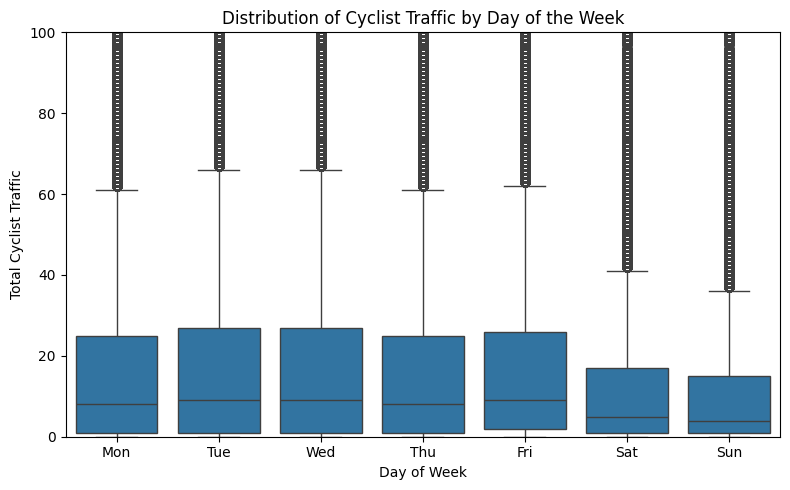

In [ ]:
xlim = 100

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_traffic_hourly.assign(
        dayofweek=pd.to_datetime(df_traffic_hourly['datehour']).dt.dayofweek
    ),
    x='dayofweek',
    y='traffic_total',
    order=range(7)
)
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title('Distribution of Cyclist Traffic by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Cyclist Traffic')
plt.xlim(-0.5, 6.5)
plt.ylim(0, xlim)
plt.tight_layout()
plt.show()

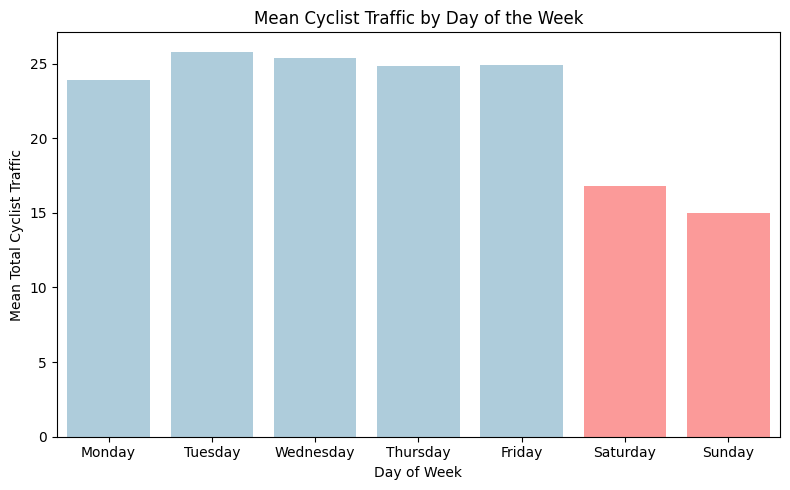

In [ ]:
# Plot mean total traffic per day of the week (Monday to Sunday) and highlight weekends
df_traffic_hourly['dayofweek'] = pd.to_datetime(df_traffic_hourly['datehour']).dt.dayofweek

dow_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traffic_by_dow = (
    df_traffic_hourly.groupby('dayofweek')['traffic_total']
    .mean()
    .reindex(range(7))  # order Monday-Sunday
    .reset_index()
)
traffic_by_dow['dow'] = traffic_by_dow['dayofweek'].map(dict(enumerate(dow_labels)))

plt.figure(figsize=(8, 5))
sns.barplot(data=traffic_by_dow, x='dow', y='traffic_total', palette=['#a6cee3']*5 + ['#fb9a99','#fb9a99'])
plt.title('Mean Cyclist Traffic by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Mean Total Cyclist Traffic')

for idx in [5, 6]:  # Saturday, Sunday
    plt.gca().patches[idx].set_facecolor('#fb9a99')

plt.tight_layout()
plt.show()


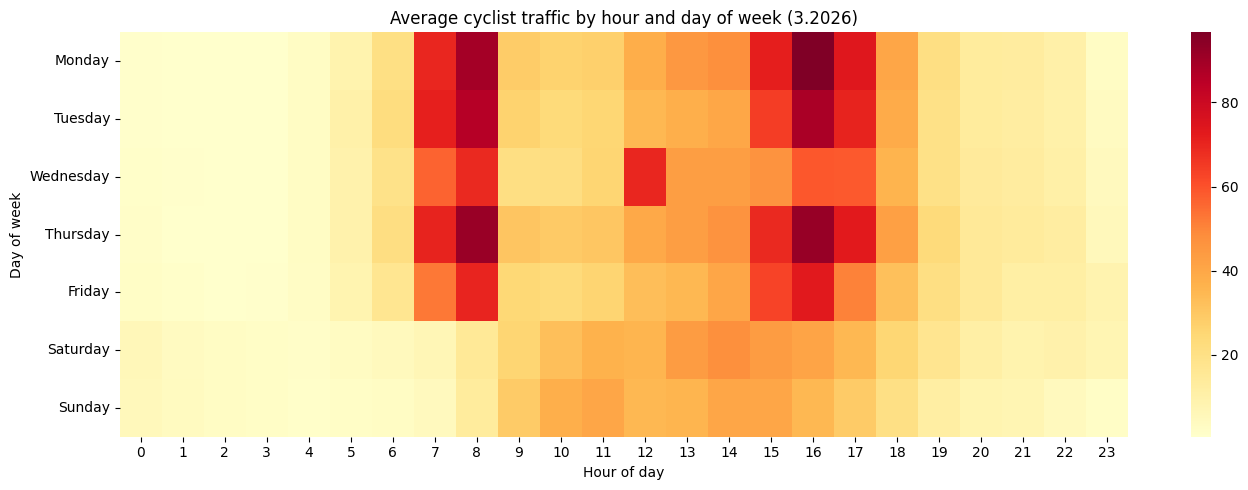

In [ ]:
# Traffic by hour and day of week in March 2026
march2026 = df_traffic_hourly.query('year_month=="2026-03"').copy()
march2026["hour"] = pd.to_datetime(march2026["datehour"]).dt.hour
march2026["dow"] = pd.to_datetime(march2026["datehour"]).dt.day_name()

heatmap_data = (march2026.groupby(["dow", "hour"])["traffic_total"].mean().reset_index())

heatmap_pivot = heatmap_data.pivot_table(
    index="dow",
    columns="hour",
    values="traffic_total",
    aggfunc="mean"
)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday","Friday", "Saturday", "Sunday"]
heatmap_pivot = heatmap_pivot.reindex(day_order)

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_pivot, cmap="YlOrRd")
plt.title("Average cyclist traffic by hour and day of week (3.2026)")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.tight_layout()
plt.savefig("heatmap_traffic.png")
plt.show()

#### Traffic by Municipalities

In [ ]:
percentiles = sorted([p/100 for p in list(range(0, 101, 10)) + [25,75,95,96,97,98,99]])
df_march = df_traffic_hourly#.query('year_month=="2026-03"')

# Function to format percentile labels
def format_percentile_label(q):
    if q < 1:
        pct = int(round(q*100))
        return f"p{pct:02d}"
    elif q == 1:
        return "p100"
    else:
        return f"p{int(round(q*100))}"

# Municipality quantiles
traffic_quantiles_by_muni = (

    df_march
    .groupby('municipality')['traffic_total']
    .quantile(percentiles)
    .unstack(level=1)
)
quantile_cols = [format_percentile_label(q) for q in traffic_quantiles_by_muni.columns]
traffic_quantiles_by_muni.columns = quantile_cols

total_quantiles_row = df_march['traffic_total'].quantile(percentiles).to_frame().T
total_quantiles_row.columns = quantile_cols
total_quantiles_row.index = ['total']

agg_traffic_per_muni = (
    df_march
    .groupby('municipality')
    .agg(
        total_traffic=('traffic_total', 'sum'),
        mean_traffic=('traffic_total', 'mean'),
        n_sites=('site_id', pd.Series.nunique)
    )
)

total_agg_row = pd.DataFrame({
    'total_traffic': [df_march['traffic_total'].sum()],
    'mean_traffic': [df_march['traffic_total'].mean()],
    'n_sites': [df_march['site_id'].nunique()]}, 
    index=['total'])

traffic_quantiles_by_muni = traffic_quantiles_by_muni.join(agg_traffic_per_muni)
traffic_quantiles_by_muni['traffic_per_site'] = np.ceil(traffic_quantiles_by_muni['total_traffic'] / traffic_quantiles_by_muni['n_sites']).astype(int)

total_quantiles_row = total_quantiles_row.join(total_agg_row)
total_quantiles_row['traffic_per_site'] = int(total_quantiles_row['total_traffic'] / total_quantiles_row['n_sites'])
traffic_quantiles_with_total = pd.concat([traffic_quantiles_by_muni, total_quantiles_row],axis=0).reset_index().rename(columns={'index':'municipality'})
traffic_quantiles_with_total['%'] = round(traffic_quantiles_with_total['total_traffic']/max(traffic_quantiles_with_total['total_traffic']),3)*100
traffic_quantiles_with_total.reset_index(drop=True).sort_values(by='total_traffic', ascending=False).reset_index(drop=True)

,municipality,p00,p10,p20,p25,p30,p40,p50,p60,p70,p75,p80,p90,p95,p96,p97,p98,p99,p100,total_traffic,mean_traffic,n_sites,traffic_per_site,%
0,total,0.0,0.0,1.0,1.0,2.0,4.0,7.0,12.0,18.0,23.0,29.0,54.0,90.00,104.00,125.00,159.00,227.00,4742.0,32690262.0,21.991697,147,222382,100.0
1,Leuven,0.0,1.0,5.0,7.0,10.0,18.0,29.0,48.0,75.0,94.0,121.0,223.0,327.00,358.00,401.00,466.00,574.00,1585.0,4076309.0,77.720962,5,815262,12.5
2,Kortrijk,0.0,0.0,3.0,5.0,7.0,12.0,17.0,25.0,37.0,46.0,57.0,114.0,238.00,273.00,318.00,383.00,519.92,970.0,2567332.0,48.990211,5,513467,7.9
3,Hasselt,0.0,4.0,10.0,14.0,20.0,34.0,54.0,80.0,109.0,125.0,143.0,196.0,248.80,264.00,284.00,311.00,358.96,1483.0,2563041.0,81.612514,3,854347,7.8
4,Nieuwpoort,0.0,0.0,2.0,3.0,4.0,8.0,14.0,23.0,35.0,44.0,57.0,114.0,187.00,215.00,258.00,319.00,425.59,1597.0,1805964.0,43.058605,4,451491,5.5
5,Gent,0.0,1.0,3.0,5.0,7.0,13.0,22.0,33.0,46.0,54.0,63.0,90.0,123.00,134.00,146.00,161.00,189.61,502.0,1526891.0,36.406557,4,381723,4.7
6,Brugge,0.0,1.0,2.0,4.0,5.0,10.0,15.0,20.0,28.0,32.0,38.0,57.0,85.00,98.00,116.00,138.00,164.00,782.0,1339403.0,24.808353,6,223234,4.1
7,Westerlo,0.0,0.0,2.0,3.0,4.0,6.0,11.0,16.0,24.0,30.0,37.0,61.0,84.00,90.00,100.00,114.00,150.00,388.0,948087.0,22.606872,4,237022,2.9
8,Dendermonde,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,40.0,59.0,83.0,144.0,212.00,245.00,292.89,338.00,398.63,896.0,944414.0,45.105263,2,472207,2.9
9,Zemst,0.0,2.0,7.0,11.0,16.0,29.0,48.0,68.0,93.0,107.0,128.0,192.0,277.00,304.28,332.00,362.64,400.00,591.0,807287.0,77.112141,1,807287,2.5


# FEATURE ENGINEERING

In [14]:
lmonth = [(f"{y}-{m:02}") for y in range(2024, 2027) for m in range(1, 13) if f"{y}-{m:02}" >= "2024-09" and f"{y}-{m:02}" <= "2026-03"]
len(lmonth), print(lmonth)

['2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']


(19, None)

In [18]:
df_infra   = pd.read_csv(FILEPATH_INFRA)
df_site    = pd.read_csv(FILEPATH_SITE, header=None, names=SITE_COLS)
df_weather = pd.read_csv(FILEPATH_WEATHER)

## 1. Neighbor traffic features

In [19]:
dfs = []
for i in lmonth:
    _df = mda_lib.compute_neighbor_traffic_lag_hour_features(
        df_traffic = pd.read_csv(PATH_TRAFFIC + f"data-{i}.csv", names=TRAFFIC_COLS),
        df_site = df_site
        )
    dfs.append(_df)
    print(f'Done {i}')
df_fts_neighbor_lag = pd.concat(dfs, ignore_index=True)
df_fts_neighbor_lag.to_csv("feature/df_fts_neighbor_lag.csv", index=False)

print(df_fts_neighbor_lag.shape) 
df_fts_neighbor_lag.head()

Done 2024-09
Done 2024-10
Done 2024-11
Done 2024-12
Done 2025-01
Done 2025-02
Done 2025-03
Done 2025-04
Done 2025-05
Done 2025-06
Done 2025-07
Done 2025-08
Done 2025-09
Done 2025-10
Done 2025-11
Done 2025-12
Done 2026-01
Done 2026-02
Done 2026-03
(2026420, 38)


,site_id,datehour,nb_r200m_lag1h_mean,nb_r200m_lag1h_max,nb_r200m_lag1h_sum,nb_r500m_lag1h_mean,nb_r500m_lag1h_max,nb_r500m_lag1h_sum,nb_r1000m_lag1h_mean,nb_r1000m_lag1h_max,...,nb_r200m_lag7d_sum,nb_r500m_lag7d_mean,nb_r500m_lag7d_max,nb_r500m_lag7d_sum,nb_r1000m_lag7d_mean,nb_r1000m_lag7d_max,nb_r1000m_lag7d_sum,nb_r2000m_lag7d_mean,nb_r2000m_lag7d_max,nb_r2000m_lag7d_sum
0,1,2024-09-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2024-09-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2024-09-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2024-09-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2024-09-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
dfs = []
for i in lmonth:
    _df = mda_lib.compute_neighbor_traffic_lag_15m_features(
        df_traffic = pd.read_csv(PATH_TRAFFIC + f"data-{i}.csv", names=TRAFFIC_COLS),
        df_site = pd.read_csv(FILEPATH_SITE, names=SITE_COLS)
        )
    dfs.append(_df)
    print(f'Done {i}')
df_fts_neighbor_lag15m = pd.concat(dfs, ignore_index=True)
df_fts_neighbor_lag15m.to_csv("feature/df_fts_neighbor_lag15m.csv", index=False)

print(df_fts_neighbor_lag15m.shape) 
df_fts_neighbor_lag15m.head()

Done 2024-09
Done 2024-10
Done 2024-11
Done 2024-12
Done 2025-01
Done 2025-02
Done 2025-03
Done 2025-04
Done 2025-05
Done 2025-06
Done 2025-07
Done 2025-08
Done 2025-09
Done 2025-10
Done 2025-11
Done 2025-12
Done 2026-01
Done 2026-02
Done 2026-03
(2026420, 14)


,site_id,datehour,nb_r200m_lag15m_mean,nb_r200m_lag15m_max,nb_r200m_lag15m_sum,nb_r500m_lag15m_mean,nb_r500m_lag15m_max,nb_r500m_lag15m_sum,nb_r1000m_lag15m_mean,nb_r1000m_lag15m_max,nb_r1000m_lag15m_sum,nb_r2000m_lag15m_mean,nb_r2000m_lag15m_max,nb_r2000m_lag15m_sum
0,1,2024-09-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2024-09-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2024-09-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2024-09-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2024-09-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Weather features

In [21]:
df_fts_weather_lag = mda_lib.compute_weather_features(df_weather)
df_fts_weather_lag.to_csv("feature/df_fts_weather_lag.csv", index=False)

print(df_fts_weather_lag.shape)
df_fts_weather_lag.head()

(1731600, 52)


,site_id,wt_temperature_2m,wt_relative_humidity_2m,wt_precipitation,wt_rain,wt_snowfall,wt_wind_speed_10m,wt_wind_direction_10m,wt_pressure_msl,wt_cloud_cover,...,wt_temperature_2m_rolling_mean_3h,wt_temperature_2m_rolling_sum_24h,wt_temperature_2m_rolling_mean_24h,wt_temp_change_1h,wt_temp_change_3h,wt_was_raining_lag1h,wt_was_raining_lag2h,wt_was_raining_lag3h,wt_consec_rain_hours,wt_first_dry_after_rain
0,2,6.4,77,0.0,0.0,0.0,7.9,179,1026.1,100,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
1,2,6.3,76,0.0,0.0,0.0,7.7,180,1025.9,100,...,6.400000,6.4,6.400000,-0.1,NaN,0,0,0,0,0
2,2,5.8,77,0.0,0.0,0.0,8.0,175,1025.5,99,...,6.350000,12.7,6.350000,-0.5,NaN,0,0,0,0,0
3,2,5.9,78,0.0,0.0,0.0,9.0,170,1024.9,95,...,6.166667,18.5,6.166667,0.1,-0.5,0,0,0,0,0
4,2,5.5,79,0.0,0.0,0.0,8.9,167,1024.5,94,...,6.000000,24.4,6.100000,-0.4,-0.8,0,0,0,0,0


## 3. Population features

In [22]:
df_fts_population = mda_lib.compute_population_features(df_site, FILEPATH_POP_TIF)
df_fts_population.to_csv("feature/df_fts_population.csv", index=False)

print(df_fts_population.shape)
df_fts_population.head()

(151, 7)


,site_id,pop_500m,density_500m,pop_1000m,density_1000m,pop_5000m,density_5000m
0,1,259.0,329.7,2754.8,876.9,99099.5,1261.8
1,2,288.2,366.9,1374.9,437.7,164971.4,2100.5
2,3,255.9,325.8,1256.4,399.9,165018.6,2101.1
3,4,249.6,317.7,851.3,271.0,27181.8,346.1
4,5,253.5,322.8,858.2,273.2,27180.3,346.1


## 4. Datetime features

In [24]:
dfs = []
for i in lmonth:
    _df = mda_lib.compute_datetime_features(df_traffic = pd.read_csv(PATH_TRAFFIC + f"data-{i}.csv", names=TRAFFIC_COLS))
    dfs.append(_df)
    print(f'Done {i}')
df_fts_datetime = pd.concat(dfs, ignore_index=True)
df_fts_datetime.to_csv("feature/df_fts_datetime.csv", index=False)

print(df_fts_datetime.shape) 
df_fts_datetime.head()

Done 2024-09
Done 2024-10
Done 2024-11
Done 2024-12
Done 2025-01
Done 2025-02
Done 2025-03
Done 2025-04
Done 2025-05
Done 2025-06
Done 2025-07
Done 2025-08
Done 2025-09
Done 2025-10
Done 2025-11
Done 2025-12
Done 2026-01
Done 2026-02
Done 2026-03
(1890048, 18)


,site_id,datehour,year,month,day,hour,dayofweek,dt_is_weekend,dt_is_weekday,dt_is_monday,dt_is_friday,dt_is_morning_rush,dt_is_afternoon_rush,dt_is_rush_hour,dt_is_lunch_hour,dt_is_night,dt_is_business_hours,dt_is_holiday
0,1,2024-09-01 00:00:00,2024,9,1,0,6,1,0,0,0,0,0,0,0,1,0,0
1,1,2024-09-01 01:00:00,2024,9,1,1,6,1,0,0,0,0,0,0,0,1,0,0
2,1,2024-09-01 02:00:00,2024,9,1,2,6,1,0,0,0,0,0,0,0,1,0,0
3,1,2024-09-01 03:00:00,2024,9,1,3,6,1,0,0,0,0,0,0,0,1,0,0
4,1,2024-09-01 04:00:00,2024,9,1,4,6,1,0,0,0,0,0,0,0,1,0,0


## 5. Infrastructure and POI features

In [25]:
df_fts_infra = mda_lib.compute_infra_features(df_infra, df_site)
df_fts_infra.to_csv("feature/df_fts_infra.csv", index=False)

print(df_fts_infra.shape)
df_fts_infra.head()

(151, 23)


,site_id,road_length_m,road_dist_to_segment_m,road_bike_lane_width_m,road_has_cycleway,poi_shop_250m,poi_shop_500m,poi_shop_1000m,poi_education_250m,poi_education_500m,...,poi_hotel_1000m,poi_hospital_250m,poi_hospital_500m,poi_hospital_1000m,road_bike_width_imputed,road_category_local_access_road,road_category_local_road,road_category_minor_road,road_category_others,road_category_regional_road
0,1,847.57,2.878127,4.0,True,0,0,1,0,0,...,0,0,0,1,False,0,0,0,1,0
1,2,398.76,7.577427,7.0,True,0,0,7,0,0,...,0,0,0,0,False,0,1,0,0,0
2,3,288.86,12.860851,7.0,True,0,0,4,0,0,...,0,0,0,0,False,0,1,0,0,0
3,4,254.23,3.525611,6.0,True,1,2,5,0,0,...,0,0,0,0,False,0,1,0,0,0
4,5,254.23,4.312523,6.0,True,1,2,5,0,0,...,0,0,0,0,False,0,1,0,0,0


# MODELING

## 1. Label

In [26]:
traffic_columns=['site_id', 'direction', 'type', 'from', 'to', 'count']
traffic_files = sorted(
    glob.glob(os.path.join(PATH_TRAFFIC, "data-2024-1*.csv")) +
    glob.glob(os.path.join(PATH_TRAFFIC, "data-2025-*.csv")) +
    glob.glob(os.path.join(PATH_TRAFFIC, "data-2026-*.csv"))
)
df_traffic = pd.concat([pd.read_csv(f, names=traffic_columns) for f in traffic_files], ignore_index=True)
print(f"{len(df_traffic):,} rows from {len(traffic_files)} files")
df_traffic = df_traffic[df_traffic["type"] == "FIETSERS"]
df_traffic['count'] = df_traffic['count'].fillna(0)
df_traffic["site_id"] = df_traffic["site_id"].astype("int32")
df_traffic["from"] = pd.to_datetime(df_traffic["from"])
df_traffic["datehour"] = pd.to_datetime(df_traffic["from"]).dt.floor("h")
df_traffic_hourly = (
    df_traffic
    .groupby(["site_id", "datehour"], as_index=False)["count"]
    .sum()
    .rename(columns={'count':'traffic_total'})
    .reset_index(drop=True)
)
df_traffic_hourly.head()

15,781,580 rows from 20 files


,site_id,datehour,traffic_total
0,1,2024-10-01 00:00:00,0.0
1,1,2024-10-01 01:00:00,0.0
2,1,2024-10-01 02:00:00,0.0
3,1,2024-10-01 03:00:00,2.0
4,1,2024-10-01 04:00:00,4.0


In [27]:
df_traffic_hourly['traffic_total'].quantile(sorted([p/100 for p in [i for i in list[int](range(0, 101, 10))+[25,95,96,97,98,99]]]))

0.00       0.0
0.10       0.0
0.20       1.0
0.25       1.0
0.30       2.0
0.40       4.0
0.50       7.0
0.60      11.0
0.70      18.0
0.80      29.0
0.90      54.0
0.95      89.0
0.96     104.0
0.97     125.0
0.98     158.0
0.99     227.0
1.00    4742.0
Name: traffic_total, dtype: float64

In [ ]:
df_label = df_traffic_hourly.copy()
df_label.shape, df_label['datehour'].min(), df_label['datehour'].max()

((1969918, 3),
 Timestamp('2024-10-01 00:00:00'),
 Timestamp('2026-05-23 03:00:00'))

In [29]:
df_label.to_csv("feature/df_label.csv", index=False)

##  2. Train - Test

In [30]:
_condition = "datehour>='2024-12-08'"
df_label               = pd.read_csv("feature/df_label.csv").query(_condition)
df_fts_neighbor_lag    = pd.read_csv("feature/df_fts_neighbor_lag.csv").query(_condition)
df_fts_neighbor_lag15m = pd.read_csv("feature/df_fts_neighbor_lag15m.csv").query(_condition)
df_fts_datetime        = pd.read_csv("feature/df_fts_datetime.csv").query(_condition)
df_fts_population      = pd.read_csv("feature/df_fts_population.csv")
df_fts_weather_lag     = pd.read_csv("feature/df_fts_weather_lag.csv").query(_condition)
df_fts_infra           = pd.read_csv("feature/df_fts_infra.csv")

print("\n".join([
    f"df_label: {df_label.shape}",
    f"df_fts_neighbor_lag: {df_fts_neighbor_lag.shape}",
    f"df_fts_neighbor_lag15m: {df_fts_neighbor_lag15m.shape}",
    f"df_fts_datetime: {df_fts_datetime.shape}",
    f"df_fts_population: {df_fts_population.shape}",
    f"df_fts_weather_lag: {df_fts_weather_lag.shape}",
    f"df_fts_infra: {df_fts_infra.shape}",
    ""
]))

df_label: (1745131, 3)
df_fts_neighbor_lag: (1671268, 38)
df_fts_neighbor_lag15m: (1671268, 14)
df_fts_datetime: (1566621, 18)
df_fts_population: (151, 7)
df_fts_weather_lag: (1706400, 52)
df_fts_infra: (151, 23)



In [33]:
df_model = (df_label
    .merge(df_fts_neighbor_lag, on=["site_id", "datehour"], how="left")
    .merge(df_fts_neighbor_lag15m, on=["site_id", "datehour"], how="left")
    .merge(df_fts_datetime, on=["site_id", "datehour"], how="left")
    .merge(df_fts_population, on=["site_id"], how="left")
    .merge(df_fts_weather_lag, on=["site_id", "datehour"], how="left")
    .merge(df_fts_infra, on=["site_id"], how="left")
    )
df_model['datehour'] = pd.to_datetime(df_model['datehour']) 
df_model['date'] = df_model['datehour'].dt.strftime('%Y-%m-%d')
# df_model['date'] = df_model['datehour'].str[:10]

df_model.to_csv('data/data_training_142fts.csv', index=False)
df_model.shape

(1745131, 146)

In [ ]:
# df_model = pd.read_csv('data/data_training_142fts.csv')
t1='2025-11-01'
t2='2026-01-01'
df_model["tvt"] = df_model["date"].apply(lambda d: "train" if d < t1 else "valid" if (d >= t1 and d<t2) else "test")

df_train = df_model[df_model["tvt"] == "train"]
df_valid = df_model[df_model["tvt"] == "valid"]
df_test = df_model[df_model["tvt"] == "test"]
# print(f"Train MIN date: {df_train['datehour'].min()} - MAX: {df_train['datehour'].max()}")
# print(f"Valid MIN date: {df_valid['datehour'].min()} - MAX: {df_valid['datehour'].max()}")
# print(f"Test  MIN date: {df_test['datehour'].min()} - MAX: {df_test['datehour'].max()}")
# print(f"TRAIN: {round(df_train.shape[0]/df_model.shape[0],2)} - VALID: {round(df_valid.shape[0]/df_model.shape[0], 2)} - TEST: {round(df_test.shape[0]/df_model.shape[0], 2)}")

In [36]:
TARGET = "traffic_total"
ID_COLS = ['site_id', 'datehour']

feature_nb = [x for x in df_model if x.startswith('nb')]
feature_wt = [x for x in df_model if x.startswith('wt')]
feature_pop = [x for x in df_model if x.startswith('pop') or x.startswith('density')]
feature_dt = [x for x in df_model if x.startswith('dt')] + ['year','month','day','hour','dayofweek',]
feature_infra = [x for x in df_model if x.startswith('road') or x.startswith('poi')]
FEATURE_COLS = feature_nb+feature_wt+feature_pop+feature_dt+feature_infra#+feature_site

print("feature_nb:", len(feature_nb))
print("feature_wt:", len(feature_wt))
print("feature_pop:", len(feature_pop))
print("feature_dt:", len(feature_dt))
print("feature_infra:", len(feature_infra))
print("ALL_FEATURES:", len(FEATURE_COLS))

X_train, y_train = mda_lib.split_traintest(df_train, list_features=FEATURE_COLS, target=TARGET)
X_val, y_val = mda_lib.split_traintest(df_valid, list_features=FEATURE_COLS, target=TARGET)
X_test, y_test = mda_lib.split_traintest(df_test, list_features=FEATURE_COLS, target=TARGET)
print(f"Train {X_train.shape}: {df_train['datehour'].min()}, {df_train['datehour'].max()}")
print(f"Valid  {X_val.shape}: {df_valid['datehour'].min()}, {df_valid['datehour'].max()}")
print(f"Test   {X_test.shape}: {df_test['datehour'].min()}, {df_test['datehour'].max()}")

feature_nb: 48
feature_wt: 50
feature_pop: 6
feature_dt: 16
feature_infra: 22
ALL_FEATURES: 142
Train (1105034, 142): 2024-12-08 00:00:00, 2025-10-31 23:00:00
Valid  (212280, 142): 2025-11-01 00:00:00, 2025-12-31 23:00:00
Test   (427817, 142): 2026-01-01 00:00:00, 2026-05-23 03:00:00


In [37]:
df_model.to_csv('data/data_training_142fts.csv', index=False)

In [38]:
# corr_matrix = df_model.sample(n=2000, random_state=42).corr(numeric_only=True)
# plt.figure(figsize=(12, 10))
# sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
# plt.title('Correlation matrix of features in df_model')
# plt.show()

# pd.options.display.max_rows=150
# corr_matrix[['traffic_total']].abs().sort_values('traffic_total', ascending=False)

## 3. Model Training


### 3.1 Base models

In [63]:
dmodels = {
    "LinearRegression": LinearRegression(n_jobs=-1, fit_intercept=True),
    "DecisionTree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=100,
        random_state=42,
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,            
        max_depth=12,               
        min_samples_leaf=50,         
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        min_samples_leaf=100,
        subsample=0.8,
        random_state=42,
        # EARLY STOPPING
        n_iter_no_change=50,         
        validation_fraction=0.15,    
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=1000,
        learning_rate=0.1,
        max_leaf_nodes=31,
        min_samples_leaf=1,
        random_state=42,
        scoring="loss",
        validation_fraction=0.15,
        n_iter_no_change=50,
    ),
    "XGBoost": XGBRegressor(
        subsample=0.8,
        reg_lambda=1.5,
        reg_alpha=0,
        random_state=42,
        n_jobs=-1,
        n_estimators=1000,
        min_child_weight=1,
        max_depth=6,
        learning_rate=0.05,
        gamma=0.2,
        colsample_bytree=0.9,
        early_stopping_rounds=50,
    ),
    "LightGBM": LGBMRegressor(
        objective="regression",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
        device="cpu",
        n_jobs=-1,
    ),
}

dict_model = mda_lib.run_models(dmodels, X_train, y_train, X_val, y_val, X_test, y_test)
pd.DataFrame(dict_model).T

Training models:   0%|          | 0/7 [00:00<?, ?it/s]

LinearRegression     - Test MAE:   19.957 | Valid MAE:   14.907 | Iter:   N/A | nfeatures:  142
DecisionTree         - Test MAE:   16.502 | Valid MAE:   11.125 | Iter:   N/A | nfeatures:  142
RandomForest         - Test MAE:   15.293 | Valid MAE:    9.949 | Iter:   N/A | nfeatures:  142
GradientBoosting     - Test MAE:   15.203 | Valid MAE:   10.700 | Iter:   N/A | nfeatures:  142


  File "c:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Admin\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\anaconda3\Lib\subprocess.

HistGradientBoosting - Test MAE:   13.621 | Valid MAE:    6.569 | Iter:  1000 | nfeatures:  142
XGBoost              - Test MAE:   14.431 | Valid MAE:    8.130 | Iter:   565 | nfeatures:  142
LightGBM             - Test MAE:   13.646 | Valid MAE:    8.233 | Iter:   282 | nfeatures:  142


,model,nfeatures,mae,rmse,valid_mae,valid_rmse,time,best_iteration
LinearRegression,LinearRegression(n_jobs=-1),142,19.957023,43.703518,14.906556,31.333821,18.040371,N/A
DecisionTree,"DecisionTreeRegressor(max_depth=10, min_sample...",142,16.501545,33.874059,11.124976,27.422084,66.801323,N/A
RandomForest,"(DecisionTreeRegressor(max_depth=12, max_featu...",142,15.29311,32.556859,9.948748,25.524983,1134.480343,N/A
GradientBoosting,([DecisionTreeRegressor(criterion='friedman_ms...,142,15.203015,36.386504,10.699808,24.706572,1372.138024,N/A
HistGradientBoosting,"HistGradientBoostingRegressor(max_iter=1000, m...",142,13.62131,36.026859,6.569255,17.765594,163.424136,1000
XGBoost,"XGBRegressor(base_score=None, booster=None, ca...",142,14.431205,36.620271,8.130046,21.223821,127.315922,565
LightGBM,"LGBMRegressor(colsample_bytree=0.8, device='cp...",142,13.64647,35.117843,8.232755,21.620209,32.525428,282


- HistGradientBoosting: Achieved the highest accuracy (Lowest MAE: 13.62), but required a lengthy training time of 163.4 seconds.
- XGBoost: Delivered a slightly lower performance compared to the other two boosting models (MAE: 14.43) while still requiring a high training time (127.32 seconds).
- LightGBM: Achieved an exceptional balance, delivering an MAE of 13.64 while computing time is quite fast at only 32.53 seconds.
- Other models are not considered due to either long training time or high MAE

--> **We select LightGBM to move forward into the next stages.**

In [40]:
df_importance = (
    pd.DataFrame({
        "feature": FEATURE_COLS,
        "importance": dict_model['LightGBM']['model'].feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
df_importance

,feature,importance
0,hour,2088
1,pop_5000m,1259
2,road_dist_to_segment_m,1244
3,month,1161
4,pop_500m,1128
...,...,...
137,wt_was_raining_lag1h,0
138,wt_snowfall_lag3h,0
139,wt_first_dry_after_rain,0
140,wt_was_raining_lag3h,0


### 3.2 Feature Selection - SHAP

SHAP sample size: 10,000 % 1,105,034 training rows


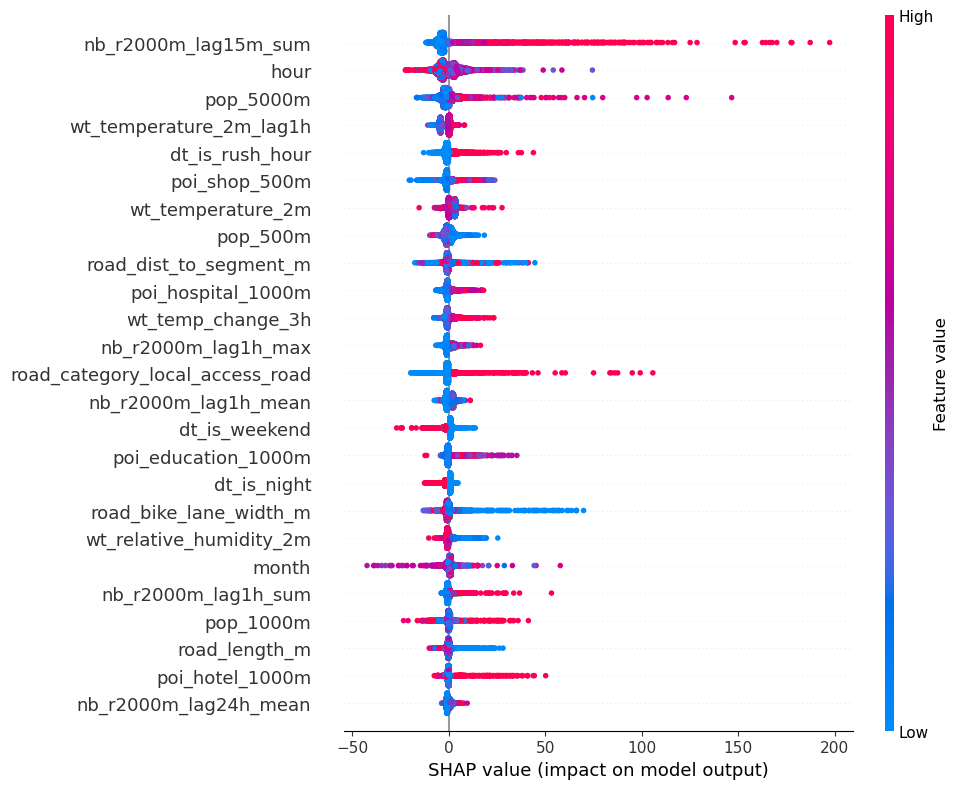

In [41]:
SHAP_SAMPLE = 10000
X_shap = X_train.sample(SHAP_SAMPLE, random_state=42)
print(f"SHAP sample size: {SHAP_SAMPLE:,} % {len(X_train):,} training rows")

explainer    = shap.TreeExplainer(dict_model['LightGBM']['model'])
shap_values  = explainer.shap_values(X_shap)

plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS, max_display=25, show=False, plot_size=(10, 8))

In [44]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
df_shap = (
    pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
df_shap["rank"]        = df_shap.index + 1
df_shap["cumulative%"] = (df_shap["mean_abs_shap"].cumsum()/ df_shap["mean_abs_shap"].sum() * 100).round(2)

thresholds = sorted(list(range(20, 101, 20))+list(range(90, 101, 2)))
counts = {}
for t in thresholds:
    counts[f"0-{t}"] = (df_shap['cumulative%'] <= t).sum()
_temp = pd.DataFrame(list(counts.items()), columns=["cumulative_bin", "cumulative_nfts"])
_temp['nfts_removed'] = len(FEATURE_COLS) - _temp['cumulative_nfts']
_temp

,cumulative_bin,cumulative_nfts,nfts_removed
0,0-20,2,140
1,0-40,9,133
2,0-60,18,124
3,0-80,35,107
4,0-90,54,88
5,0-92,59,83
6,0-94,66,76
7,0-96,75,67
8,0-98,89,53
9,0-100,142,0


- Out of total 142 features, we only need nearly 1/3 of them (54 features) to explain 90% model. 
- This will reduce model complexity and computing time.
- Next, we will drop 88 features from the original model and keep 54 features with the highest SHAP value.

In [ ]:
FEATURE_COLS_SHAP = df_shap[df_shap["cumulative%"] <= 88]['feature'].to_list()
print(len(FEATURE_COLS_SHAP))

X_train_sel = X_train[FEATURE_COLS_SHAP]
X_val_sel = X_val[FEATURE_COLS_SHAP]
X_test_sel = X_test[FEATURE_COLS_SHAP]
print(f"X_train_sel: {X_train_sel.shape} | X_val_sel: {X_val_sel.shape} | X_test_sel : {X_test_sel.shape}")

54
X_train_sel: (1105034, 54) | X_val_sel: (212280, 54) | X_test_sel : (427817, 54)


In [46]:
dict_model.update(
    mda_lib.run_models({"LightGBM_SHAP": LGBMRegressor(**dmodels["LightGBM"].get_params())}, 
    X_train_sel, y_train, X_val_sel, y_val, X_test_sel, y_test)
)

Training models:   0%|          | 0/1 [00:00<?, ?it/s]

LightGBM_SHAP        - Test MAE:   13.684 | Valid MAE:    6.759 | Iter:   997 | nfeatures:   54


In [47]:
pd.DataFrame(dict_model).T

,model,nfeatures,mae,rmse,valid_mae,valid_rmse,time,best_iteration
LightGBM,"LGBMRegressor(colsample_bytree=0.8, device='cp...",142,13.353916,34.916475,6.791813,18.241445,80.129936,999
LightGBM_SHAP,"LGBMRegressor(colsample_bytree=0.8, device='cp...",54,13.683646,35.49928,6.759062,18.332469,56.249859,997


- As expected, cutting of ~1/3 initial number of features helps reducing training from 80.13s to 56.25s, even though the MAE only slightly increase from 13.35 to 13.68, which is not significant.
- Next, we will tune model hypermeter.

### 3.3 Hyperparameters Tuning

In [48]:
param_distributions = {
    'n_estimators': [800, 1000, 1200],
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': [31, 63, 127], 
    'min_child_samples': [50, 100],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 1],  
    'reg_lambda': [0, 0.1, 1],
    'objective': ["regression"],
    'random_state': [42],
    'device': ["cpu"],
    'n_jobs': [-1],
    'verbose': [-1]
}

random_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(),
    param_distributions=param_distributions,
    n_iter=10,                 
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=3),  
    verbose=1,             
    random_state=42,
    n_jobs=1      
)

random_search.fit(X_train_sel, y_train)
print(f"Best Parameters Found: {random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found: {'verbose': -1, 'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 1, 'random_state': 42, 'objective': 'regression', 'num_leaves': 63, 'n_jobs': -1, 'n_estimators': 1000, 'min_child_samples': 100, 'learning_rate': 0.03, 'device': 'cpu', 'colsample_bytree': 0.7}


In [49]:
dict_model.update(
    mda_lib.run_models({"LightGBM_SHAP_tuned": random_search.best_estimator_}, X_train_sel, y_train, X_val_sel, y_val, X_test_sel, y_test)
)

Training models:   0%|          | 0/1 [00:00<?, ?it/s]

LightGBM_SHAP_tuned  - Test MAE:   13.260 | Valid MAE:    6.518 | Iter:   999 | nfeatures:   54


In [50]:
pd.DataFrame(dict_model).T

,model,nfeatures,mae,rmse,valid_mae,valid_rmse,time,best_iteration
LightGBM,"LGBMRegressor(colsample_bytree=0.8, device='cp...",142,13.353916,34.916475,6.791813,18.241445,80.129936,999
LightGBM_SHAP,"LGBMRegressor(colsample_bytree=0.8, device='cp...",54,13.683646,35.49928,6.759062,18.332469,56.249859,997
LightGBM_SHAP_tuned,"LGBMRegressor(colsample_bytree=0.7, device='cp...",54,13.260069,35.803593,6.518468,18.065845,86.054867,999


- The parameter tunning process has achieved the lowest MAE so far, at `13.26`.
- Next, we conduct sequential feature selection with both adding and removing features in order to obtain both the less complex model and better MAE score

### 3.3 Feature Selection - Stepwise

In [51]:
_model     = dict_model['LightGBM_SHAP_tuned']['model']
_params    = _model.get_params()
_lfeatures = _model.feature_name_
print('>>>> Number of features:', len(_lfeatures))

features_rm, dmodel_rm = mda_lib.stepwise_feature_selection_lgb(
    mode='remove',
    list_feature_all=_lfeatures,
    base_model=_model,
    X_train=X_train_sel, 
    y_train=y_train,
    X_valid=X_val_sel, 
    y_valid=y_val,
    model_params=_params
)

>>>> Number of features: 54
Remove: nb_r2000m_lag15m_sum                               | MAE: 6.70156 | current MAE: 6.69221
Remove: hour                                               | MAE: 7.39708 | current MAE: 6.69221
Remove: pop_5000m                                          | MAE: 6.68253 | current MAE: 6.69221
  => [REMOVED]: pop_5000m                                          | New Base MAE: 6.68253
Remove: wt_temperature_2m_lag1h                            | MAE: 6.66340 | current MAE: 6.68253
  => [REMOVED]: wt_temperature_2m_lag1h                            | New Base MAE: 6.66340
Remove: dt_is_rush_hour                                    | MAE: 6.64931 | current MAE: 6.66340
  => [REMOVED]: dt_is_rush_hour                                    | New Base MAE: 6.64931
Remove: poi_shop_500m                                      | MAE: 6.70779 | current MAE: 6.64931
Remove: wt_temperature_2m                                  | MAE: 6.71822 | current MAE: 6.64931
Remove: pop_500m    

In [52]:
_model_rm     = dmodel_rm[min(dmodel_rm, key=lambda k: dmodel_rm[k]['MAE'])]['model']
_lfeatures_rm = _model_rm.feature_name_

dict_model.update(
    mda_lib.run_models({"LightGBM_SHAP_tuned_reduced": _model_rm}, 
    X_train[_lfeatures_rm], y_train, X_val[_lfeatures_rm], y_val, X_test[_lfeatures_rm], y_test)
)

Training models:   0%|          | 0/1 [00:00<?, ?it/s]

LightGBM_SHAP_tuned_reduced - Test MAE:   13.297 | Valid MAE:    6.367 | Iter:  1000 | nfeatures:   43


- After remove sequential 11 features (from `LightGBM_SHAP_tuned` with 54 features to 43 features), the model's MAE decrease from `6.69221` to `6.54912` in evaluating the valid set.
- We then evaluated the test set and also obtain similar MAE for this removed feature model `LightGBM_SHAP_tuned_reduced`.

In [53]:
print('>>>> Current number of features:', len(_lfeatures_rm))

features_add, dmodel_add = mda_lib.stepwise_feature_selection_lgb(
    mode='add',
    list_feature_all=_lfeatures,
    base_model=_model_rm,
    X_train=X_train, 
    y_train=y_train,
    X_valid=X_val, 
    y_valid=y_val,
    model_params=_model_rm.get_params()
)

>>>> Current number of features: 43
Add: pop_5000m                                          | MAE: 6.66858 | current MAE: 6.54912
Add: wt_temperature_2m_lag1h                            | MAE: 6.63825 | current MAE: 6.54912
Add: dt_is_rush_hour                                    | MAE: 6.62246 | current MAE: 6.54912
Add: dt_is_weekend                                      | MAE: 6.58320 | current MAE: 6.54912
Add: poi_education_1000m                                | MAE: 6.62952 | current MAE: 6.54912
Add: road_bike_lane_width_m                             | MAE: 6.64033 | current MAE: 6.54912
Add: wt_relative_humidity_2m                            | MAE: 6.70201 | current MAE: 6.54912
Add: nb_r2000m_lag1h_sum                                | MAE: 6.59679 | current MAE: 6.54912
Add: poi_hotel_1000m                                    | MAE: 6.61799 | current MAE: 6.54912
Add: nb_r2000m_lag7d_sum                                | MAE: 6.62416 | current MAE: 6.54912
Add: nb_r2000m_lag24h_su

In [54]:
pd.DataFrame(dict_model).T

,model,nfeatures,mae,rmse,valid_mae,valid_rmse,time,best_iteration
LightGBM,"LGBMRegressor(colsample_bytree=0.8, device='cp...",142,13.353916,34.916475,6.791813,18.241445,80.129936,999
LightGBM_SHAP,"LGBMRegressor(colsample_bytree=0.8, device='cp...",54,13.683646,35.49928,6.759062,18.332469,56.249859,997
LightGBM_SHAP_tuned,"LGBMRegressor(colsample_bytree=0.7, device='cp...",54,13.260069,35.803593,6.518468,18.065845,86.054867,999
LightGBM_SHAP_tuned_reduced,"LGBMRegressor(colsample_bytree=0.7, device='cp...",43,13.297171,35.969782,6.367019,17.717804,79.186866,1000


- After sequentially adding 11 features we removed from previous step, no added feature can help improve MAE.
- Hence, our **finalmodel ** (`LightGBM_SHAP_tuned_reduced`) has 44 features and obtain `MAE = 13.297171` for `test set` and `MAE = 6.367019` for valid set 

In [55]:
pd.to_pickle(dict_model,'dmodel_final.pickle')
pd.to_pickle(dict_model['LightGBM_SHAP_tuned_reduced']['model'],'model_final.pickle')

### 3.4 Interpretation of final model

SHAP sample size: 10,000 % 1,105,034 training rows


Text(0.5, 1.0, 'SHAP Analysis — LightGBM_SHAP_tuned_reduced (44 features)')

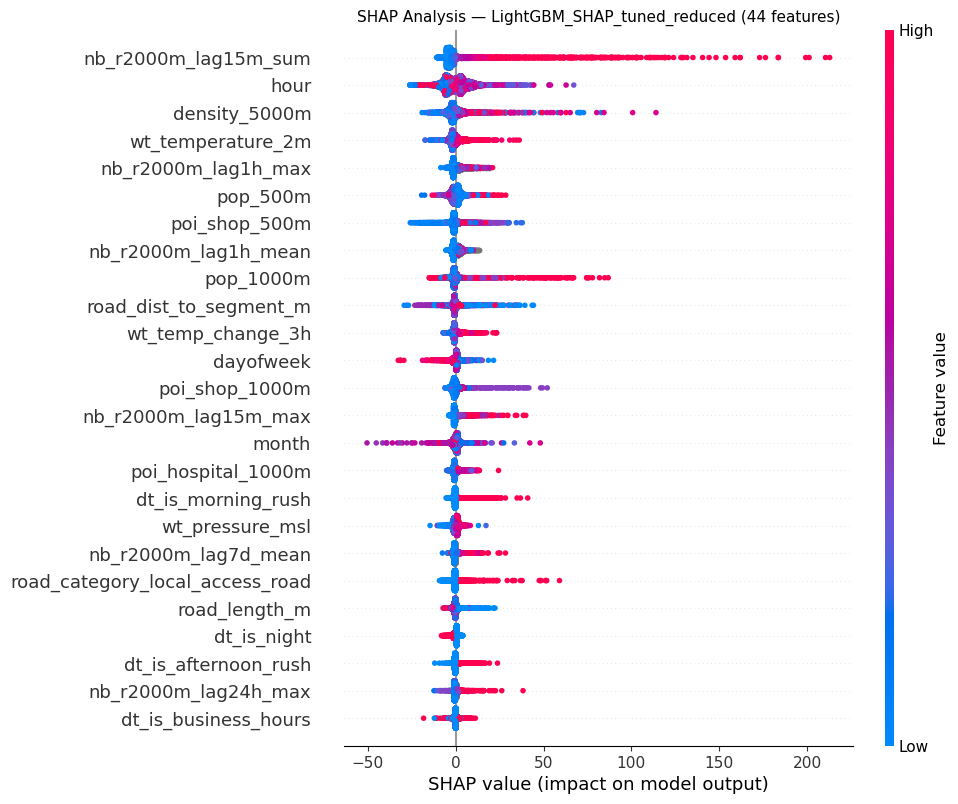

In [62]:
final_model = pd.read_pickle('model_final.pickle')
final_features = final_model.feature_name_ 

SHAP_SAMPLE = 10000
X_train_final = df_model[df_model['tvt'] == 'train'][final_features]
X_SHAP_final = X_train_final.sample(n=SHAP_SAMPLE, random_state=42)
print(f"SHAP sample size: {SHAP_SAMPLE:,} % {len(X_train):,} training rows")

explainer_final   = shap.TreeExplainer(final_model)
shap_values_final = explainer_final.shap_values(X_SHAP_final)

plt.figure()
shap.summary_plot(shap_values_final,X_SHAP_final,feature_names=final_features,max_display=25,show=False,plot_size=(10, 8),)
plt.title("SHAP Analysis — LightGBM_SHAP_tuned_reduced (44 features)", fontsize=11)
# plt.tight_layout()
# plt.savefig("shap_final.png", dpi=150, bbox_inches="tight")
# plt.show()

In [ ]:
df_features = pd.DataFrame(final_features, columns=['feature_name'])
df_features.to_csv('final_features.csv', index=False)

The SHAP analysis confirms the key drivers of cycling demand:

- *Neighbour Traffic (nb_r2000m_lag15m_sum)*:  the strongest predictor overall; the sum of cyclist counts at nearby sensors within 2 km over the preceding 15 minutes produces the widest variance in predicted demand (SHAP values reaching +200), confirming that spatial autocorrelation is the dominant driver of cyclist volume

- *Temporal and Calendar (hour)* : the second strongest predictor; the hour feature produces a wide SHAP spread (approximately −50 to +50), with morning and afternoon rush-hour flags further reinforcing the strong temporal cycle driving cycling demand

- *Population Density (density_5000m)*: areas with higher residential density within 5 km consistently drive up predicted counts, with local population counts within 500 m and 1 km further reinforcing that denser surroundings are strongly associated with increased cycling activity

- *Weather (wt_temperature_2m)*: temperature and atmospheric pressure act as consistent moderators; rising temperatures and improving thermal conditions encourage cycling, while higher atmospheric pressure associated with clear weather is linked to increased activity